In [18]:
import re
import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import networkx as nx
from collections import Iterable, Counter
from pylab import rcParams
# plt.rcParams['font.sans-serif']=['SimHei']
# plt.rcParams['figure.figsize']=['1000', '600']
# plt.rcParams['axes.unicode_minus']=False

In [2]:
data = pd.read_csv("mingjiang/detail.csv",usecols=["Title","Author","Wechat_NN","Layer","Address","Gender","Time","Stay","Share2Moment","Share2Friend","Read","Belong2"])
data.head()

,Title,Author,Wechat_NN,Layer,Address,Gender,Time,Stay,Share2Moment,Share2Friend,Read,Belong2
0,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,A小懒猫,7,中国 天津,女,2017-08-03 22:24:04.0,0,0,0,1,香奈儿
1,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,小幸运,7,云南大理,女,2017-08-03 14:34:44.0,0,0,0,2,香奈儿
2,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,  妞,7,陕西西安,女,2017-08-03 22:24:04.0,0,0,0,1,香奈儿
3,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,A慢热型男,7,陕西西安,女,2017-08-03 22:24:05.0,0,0,0,1,香奈儿
4,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,cqy苒燕,7,浙江绍兴,女,2017-08-03 22:24:05.0,0,0,0,1,香奈儿


In [61]:
title=u'眼要急！手要快！装修特权卡全城抢疯了'
data_1=data[data.Title==title]
author_list=[u'李总',u'冯胜禄',u'张文娇']
author=author_list[0]
data_1=data_1[data_1.Author==author]

In [62]:
name=data_1.Wechat_NN.tolist()
layers=data_1.Layer.tolist()
G = nx.Graph()
G.add_node(author)
max_layer=max(data_1.Layer)
color_list=['firebrick','teal','tan','cornflowerblue','salmon','olive','rosybrown','plum','gold','peru','skyblue']
visited=[]
layer_list=[]
node_color=['firebrick']
# max_layer
for layer in range(1,max_layer+1):
    for index, row in data_1.iterrows():
        if row.Layer==layer and row.Wechat_NN not in visited:
            if layer==1:
                G.add_node(row.Wechat_NN, layer=layer)
                G.add_edge(row.Wechat_NN,author)
                node_color.append(color_list[layer])
                layer_list.append(layer)
            else:
                try:
                    parent_layer=layer_list[visited.index(row.Belong2)]
                except:
                    parent_layer=layer-1
                G.add_node(row.Wechat_NN, layer=parent_layer)
                G.add_edge(row.Wechat_NN,row.Belong2)
                node_color.append(color_list[layer%11])
                layer_list.append(parent_layer)
            visited.append(row.Wechat_NN)


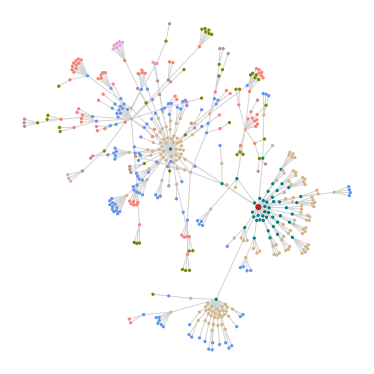

In [71]:
node_size=[25]+[5]*(len(G.nodes())-1)
nx.draw_spring(G, node_color=node_color,edge_color='lightgray',node_size=node_size)
plt.rcParams['figure.figsize']=4, 8
plt.savefig("Graph_7.png", format="PNG",dpi=500,facecolor='w')

In [13]:
|nx.check_planarity(G)

(True, <networkx.algorithms.planarity.PlanarEmbedding at 0x12196d9e8>)

In [19]:
data_1=data[data.Title==title]
c=Counter(data_1.Author)
c

Counter({'傅健': 1,
         '李春': 16,
         '谢成名': 4,
         '赵婷': 11,
         '余静': 6,
         '蔡美玉': 2,
         '熊苗苗': 3,
         '熊轩艺': 6,
         '黄潇潇': 6,
         '贾梓良': 4,
         '瞿晶晶': 17,
         '蒋梓良': 21,
         '曾文强': 3,
         '胡莹': 2,
         '阳志伟': 3,
         '丁壮志': 46,
         '向辉': 3,
         '张露枚': 4,
         '李思': 6,
         '吴昌龙': 11,
         '常取胜': 3,
         '谢冰源': 14,
         '李鹏': 7,
         '卿伟': 415,
         '郭春方': 19,
         '肖建林': 187,
         '向阳': 119,
         '陶伟': 7,
         '孙智慧': 24,
         '罗小南': 7,
         '夏晨曦': 8,
         '文念旭（文静）': 6,
         '熊辉': 11,
         '朱方青': 2,
         '何嘉奇': 1,
         '龙海': 10,
         '吴灿': 45,
         '蔡方纯': 4,
         '杨娇': 4,
         '柴婷': 131,
         '黄宝泉': 4,
         '万勇': 1,
         '朱承宇': 7,
         '伍柳枝': 1,
         '刘延丽': 20,
         '毛张霞': 3,
         '邹彬': 6,
         '禹潮野': 5,
         '杨劲槐': 20,
         '周丽霞': 1,
         '胡绘': 3,
         '冯令': 2,
      